In [1]:
import json
import os

path = os.path.join(os.getcwd(), "data_for_git/query_hierarchical_clusters.jsonl")
cluster_data = []
for line in open(path):
    cluster_data.append(json.loads(line))



In [2]:
sequence_number_of_facts = []
for query in cluster_data:
    sequence_ids = query["sequence_ids"]
    sequence_id_counter = [0 for _ in range(len(sequence_ids))]

    for i, seq_id in enumerate(sequence_ids):
        match_found = False
        for cluster in query["clusters"]:
            for fact in cluster["atomic_facts"]:
                if fact["from_sequence"] == seq_id:
                    sequence_id_counter[i] += 1
                    break

    sequence_number_of_facts.append(sequence_id_counter)

In [3]:
# flatten the list of lists
sequence_number_of_facts = [item for sublist in sequence_number_of_facts for item in sublist]


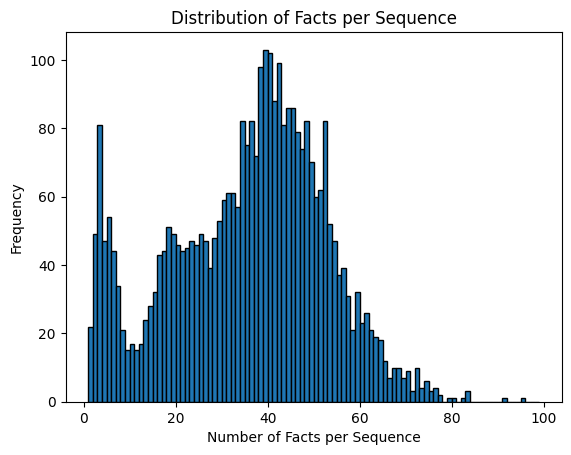

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.hist(sequence_number_of_facts, bins=range(1, 100), edgecolor='black')
plt.xlabel('Number of Facts per Sequence')
plt.ylabel('Frequency')
plt.title('Distribution of Facts per Sequence')
plt.show()



In [5]:
# Count, per sequence, clusters that are not entailed by any other cluster
unentailed_clusters_per_sequence = []

for query in cluster_data:
    sequence_ids = query["sequence_ids"]
    seq_index = {sid: idx for idx, sid in enumerate(sequence_ids)}
    clusters = query["clusters"]
    adj = query["adj"]  # adjacency list of entailments: u -> v means u entails v

    # Build set of nodes with at least one incoming edge (i.e., entailed by another cluster)
    has_incoming = set()
    for src, targets in enumerate(adj):
        for tgt in targets:
            has_incoming.add(tgt)

    counts = [0] * len(sequence_ids)
    for cluster_idx, cluster in enumerate(clusters):
        if cluster_idx in has_incoming:
            continue  # skip clusters that are entailed by some other cluster

        for fact in cluster["atomic_facts"]:
            seq_id = fact["from_sequence"]
            seq_idx = seq_index.get(seq_id)
            if seq_idx is not None:
                counts[seq_idx] += 1  # count this unentailed cluster for that sequence
                break  # only count once per cluster

    unentailed_clusters_per_sequence.append(counts)

# Optional: flatten for quick aggregation/plotting
unentailed_counts_flat = [c for sub in unentailed_clusters_per_sequence for c in sub]



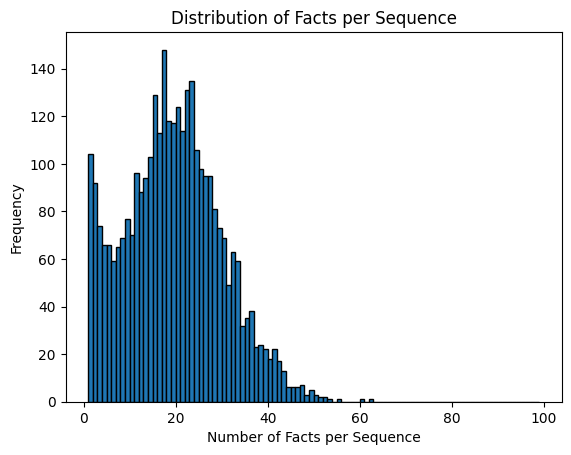

In [6]:
plt.hist(unentailed_counts_flat, bins=range(1, 100), edgecolor='black')
plt.xlabel('Number of Facts per Sequence')
plt.ylabel('Frequency')
plt.title('Distribution of Facts per Sequence')
plt.show()


In [ ]:
# Extract per-sequence cluster presence directly from precomputed sequence_presence
sequence_cluster_presence = []  # list per query; each is {seq_id: {cluster_id: presence}}

for query in cluster_data:
    sequence_ids = query["sequence_ids"]
    clusters = query["clusters"]

    seq_to_presence = {seq_id: {} for seq_id in sequence_ids}

    # sequence_presence aligns with sequence_ids order
    for cluster in clusters:
        cluster_id = cluster["id"]
        presence_list = cluster.get("sequence_presence", [])
        for seq_id, presence in zip(sequence_ids, presence_list):
            seq_to_presence[seq_id][cluster_id] = presence

    sequence_cluster_presence.append(seq_to_presence)



In [ ]:
folds_path = os.path.join(os.getcwd(), "data_for_git", "all_query_folds.jsonl")
all_query_folds = []
with open(folds_path, "r") as f:
    for line in f:
        all_query_folds.append(json.loads(line))

In [35]:
import tqdm.notebook as tqdm

# Build pairwise features using folds (one sequence held out per query)
# all_query_folds: outer list over queries, inner list over folds for that query
# For each query/fold:
# 1) Identify missing sequence.
# 2) Find clusters present in the held-out sequence.
# 3) For each remaining sequence, for any cluster present in both that sequence and the held-out one,
#    pair it with every other cluster present in that sequence, and collect features based on training sequences only.
fold_pair_features = []

using_folds = all_query_folds

with tqdm.tqdm(total=len(using_folds) * 5) as pbar:
    for q_idx, query_folds in enumerate(using_folds):
        full_query = cluster_data[q_idx]
        full_seq_ids = full_query["sequence_ids"]

        # Pre-map cluster_id -> presence list (aligned to full_seq_ids)
        cluster_presence = {c["id"]: c["sequence_presence"] for c in full_query["clusters"]}

        for fold_idx, fold in enumerate(query_folds):
            fold_seq_ids = fold["query"]["sequence_ids"]
            fold_clusters = fold["query"].get("clusters", [])
            fold_adj = fold.get("adj", [])  # adj is stored at fold top-level
            fold_id_to_idx = {c["id"]: idx for idx, c in enumerate(fold_clusters)}

            missing = list(set(full_seq_ids) - set(fold_seq_ids))
            if len(missing) != 1:
                raise ValueError(f"Expected exactly one missing sequence for query {q_idx} fold {fold_idx}, got {missing}")
            missing_seq_id = missing[0]
            missing_seq_idx = full_seq_ids.index(missing_seq_id)

            # Training (non-held-out) sequence indices
            train_indices = [full_seq_ids.index(seq_id) for seq_id in fold_seq_ids]
            n_train = len(train_indices)

            # Clusters that appear in the held-out sequence
            holdout_clusters = {cid for cid, pres in cluster_presence.items() if pres[missing_seq_idx] > 0}

            # Collect candidate pairs from sequences in the fold
            candidate_pairs = set()
            for seq_id in fold_seq_ids:
                seq_idx = full_seq_ids.index(seq_id)
                clusters_in_seq = [cid for cid, pres in cluster_presence.items() if pres[seq_idx] > 0]

                for ci in clusters_in_seq:
                    if ci not in holdout_clusters:
                        continue  # only consider clusters that also appear in hold-out
                    for cj in clusters_in_seq:
                        if ci == cj:
                            continue
                        pair = tuple(sorted((ci, cj)))
                        candidate_pairs.add(pair)

            # Compute features for each pair using training sequences only (exclude hold-out to avoid leakage)
            pair_feature_list = []
            for ci, cj in candidate_pairs:
                idx_i = fold_id_to_idx.get(ci)
                idx_j = fold_id_to_idx.get(cj)
                if idx_i is None or idx_j is None:
                    continue  # cluster not present in fold view
                # Skip entailed pairs using fold hierarchy (hold-out excluded)
                if  idx_j in fold_adj[idx_i]:
                    continue
                if  idx_i in fold_adj[idx_j]:
                    continue
                p_i = cluster_presence[ci]
                p_j = cluster_presence[cj]

                prod = [p_i[k] * p_j[k] for k in train_indices]
                if sum(prod) == 0:
                    continue  # skip pairs that never co-occur in training (ensures feature1 non-zero)

                feat1 = sum(prod) / n_train  # mean(presence_i * presence_j) on training sequences
                mean_i = sum(p_i[k] for k in train_indices) / n_train
                mean_j = sum(p_j[k] for k in train_indices) / n_train
                feat2 = mean_i * mean_j
                feat3 = sum(abs(p_i[k] - p_j[k]) for k in train_indices) / n_train
                feat4 = p_i[missing_seq_idx] * p_j[missing_seq_idx]  # hold-out sequence

                pair_feature_list.append({
                    "pair": (ci, cj),
                    "query_index": q_idx,
                    "fold_index": fold_idx,
                    "missing_sequence_id": missing_seq_id,
                    "feature1_mean_prod": feat1,
                    "feature2_mean_times_mean": feat2,
                    "feature3_mean_abs_diff": feat3,
                    "feature4_holdout_prod": feat4,
                })

            fold_pair_features.extend(pair_feature_list)
            pbar.update(1)



  0%|          | 0/3415 [00:00<?, ?it/s]

In [39]:
# no_dissapointments = [x for x in fold_pair_features if x["feature4_holdout_prod"] == 0]
# print(len(no_dissapointments))
# print(len(fold_pair_features))

data = [{
    "feature1_mean_prod": x["feature1_mean_prod"],
    "feature2_mean_times_mean": x["feature2_mean_times_mean"],
    "feature3_mean_abs_diff": x["feature3_mean_abs_diff"],
    "feature4_holdout_prod": x["feature4_holdout_prod"],
} for x in fold_pair_features]



In [41]:
df = pl.DataFrame(data)

data_numpy = df.to_numpy()







In [45]:
print(len(data_numpy[:,3]))

6905396


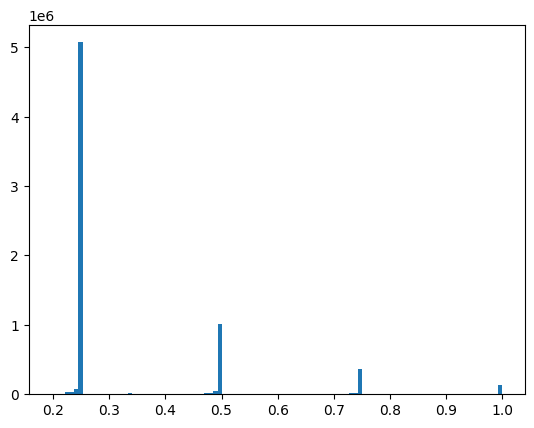

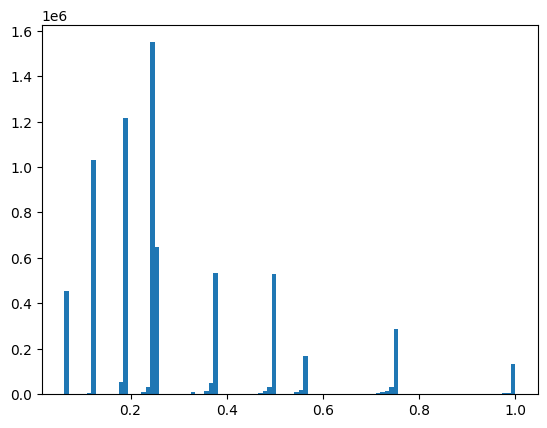

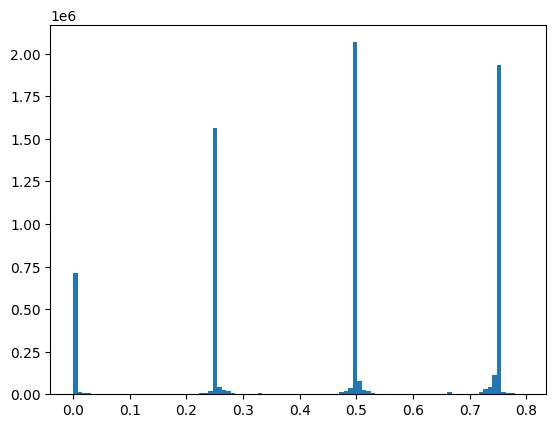

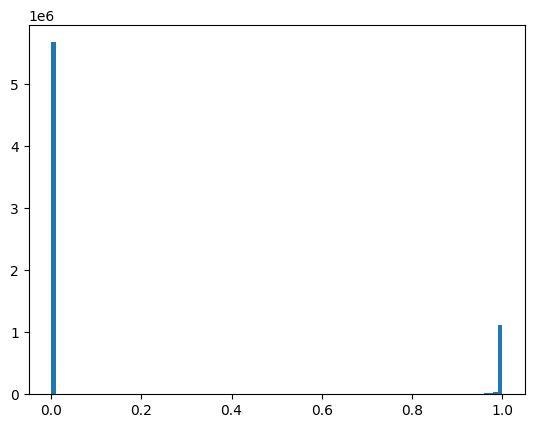

In [52]:
import matplotlib.pyplot as plt

plt.hist([data_numpy[:,0]], bins=100)
plt.show()
plt.hist([data_numpy[:,1]], bins=100)
plt.show()
plt.hist([data_numpy[:,2]], bins=100)
plt.show()
plt.hist([data_numpy[:,3]], bins=100)
plt.show()



In [48]:
import numpy as np
import polars as pl
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import joblib

# ==========================================
# 1. LOAD / PREPARE DATA
# ==========================================
# Assuming 'collected_pairs' is your list of dicts from the collection loop
# item format: {'x_joint': 0.5, 'x_prod': 0.1, 'x_div': 0.2, 'y_target': 0.0}

print("Preparing Training Matrices...")

# Convert to Numpy for Scikit-Learn
# Feature Order: [Historical_Joint, Historical_Product, Historical_Divergence]
X_data = []
y_data = []


for item in fold_pair_features:
    # Final Safety Check: Ensure we aren't training on empty targets if filtered incorrectly
    # (Though your collection logic should have handled this)
    # Original values
    raw_joint = item["feature1_mean_prod"]
    raw_prod  = item['feature2_mean_times_mean']
    raw_div   = item['feature3_mean_abs_diff']

    # NEW ORTHOGONAL FEATURES
    # 1. Baseline: What we expect by chance
    x_baseline = raw_prod

    # 2. Excess Glue (Covariance): How much MORE they appear together than chance
    # This forces the model to measure the value of the "Link" specifically.
    x_excess = raw_joint - raw_prod

    # 3. Divergence: Instability
    x_divergence = raw_div

    X_data.append([x_baseline, x_excess, x_divergence])
    y_data.append(item['feature4_holdout_prod'])

X = np.array(X_data)
y = np.array(y_data)

print(f"Training on {len(X)} pair instances.")

# ==========================================
# 2. TRAIN REGRESSION MODEL
# ==========================================
# We use Ridge with alpha=1.0. 
# This regularization prevents the model from over-reacting to outliers.
# You can increase alpha (e.g., 10.0) if you want more "conservative" global smoothing.

clf = Ridge(alpha=1.0, fit_intercept=True)
clf.fit(X, y)

# ==========================================
# 3. ANALYZE RESULTS (The White Box Check)
# ==========================================

# Coefficients
beta_joint = clf.coef_[0]   # Should be POSITIVE (History predicts Future)
beta_prod = clf.coef_[1]    # Should be POSITIVE (Base probability)
beta_div = clf.coef_[2]     # Should be NEGATIVE (Instability predicts breakup)
intercept = clf.intercept_

print("\n--- MODEL COEFFICIENTS ---")
print(f"Intercept (Base Bias):           {intercept:.4f}")
print(f"Beta 1 (History Joint):          {beta_joint:.4f}  <-- Strength of 'Glue'")
print(f"Beta 2 (Independence Baseline):  {beta_prod:.4f}   <-- Weight of Random Chance")
print(f"Beta 3 (Divergence/Instability): {beta_div:.4f}   <-- Penalty for Disagreement")

# Sanity Logic Check
if beta_joint > 0 and beta_div < 0:
    print("\n✅ PHYSICS CHECK PASSED: The model rewards consistency and penalizes divergence.")
else:
    print("\n⚠️ PHYSICS CHECK FAILED: Coefficients are counter-intuitive. Check data normalization.")

# Performance Metrics
y_pred = clf.predict(X)
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"\nR^2 Score: {r2:.4f} (Expected to be low, ~0.1-0.3, due to high noise in text gen)")
print(f"MSE:       {mse:.4f}")

# ==========================================
# 4. SAVE MODEL
# ==========================================
model_filename = "joint_probability_regressor.pkl"
joblib.dump(clf, model_filename)
print(f"\nModel saved to {model_filename}")

Preparing Training Matrices...
Training on 6905396 pair instances.

--- MODEL COEFFICIENTS ---
Intercept (Base Bias):           0.1218
Beta 1 (History Joint):          0.5920  <-- Strength of 'Glue'
Beta 2 (Independence Baseline):  -0.3806   <-- Weight of Random Chance
Beta 3 (Divergence/Instability): -0.2139   <-- Penalty for Disagreement

✅ PHYSICS CHECK PASSED: The model rewards consistency and penalizes divergence.

R^2 Score: 0.1298 (Expected to be low, ~0.1-0.3, due to high noise in text gen)
MSE:       0.1260

Model saved to joint_probability_regressor.pkl


In [ ]:
import numpy as np

def predict_joint_probability_orthogonal(hist_vec_A, hist_vec_B, model):
    """
    Predicts E[P(A, B)] using the orthogonalized features [Base, Excess, Div].
    """
    # 1. Calculate Raw Stats from History (4-fold vectors)
    raw_joint = np.mean(hist_vec_A * hist_vec_B)
    raw_prod  = np.mean(hist_vec_A) * np.mean(hist_vec_B)
    raw_div   = np.mean(np.abs(hist_vec_A - hist_vec_B))
    
    # 2. Construct Features (MUST MATCH TRAINING ORDER)
    # Feature 0: Baseline (Independence Expectation)
    x_baseline = raw_prod
    
    # Feature 1: Excess Glue (Covariance)
    x_excess = raw_joint - raw_prod
    
    # Feature 2: Divergence
    x_divergence = raw_div
    
    # 3. Predict
    # Model returns the predicted Joint Probability
    pred_joint = model.predict([[x_baseline, x_excess, x_divergence]])[0]
    
    # 4. Logical Clamping
    # Joint prob cannot be < 0
    # Joint prob cannot be > P(A) or P(B) (Upper bound)
    upper_bound = min(np.mean(hist_vec_A), np.mean(hist_vec_B))
    
    return max(0.0, min(pred_joint, upper_bound))

In [ ]:
import numpy as np

# Your Trained Coefficients (Hardcoded for simulation)
INTERCEPT = 0.1218
BETA_BASE = 0.5920    # Feature 0: Product of Means
BETA_EXCESS = -0.3806 # Feature 1: Joint - Product
BETA_DIV = -0.2139    # Feature 2: Divergence

def test_pair_discount(name, vec_a, vec_b):
    # 1. Convert to Numpy
    h_a = np.array(vec_a)
    h_b = np.array(vec_b)
    
    # 2. Calculate Raw Stats
    mean_a = np.mean(h_a)
    mean_b = np.mean(h_b)
    
    raw_joint = np.mean(h_a * h_b)
    raw_prod  = mean_a * mean_b
    raw_div   = np.mean(np.abs(h_a - h_b))
    
    # 3. Construct Features (Orthogonal)
    x_base = raw_prod
    x_excess = raw_joint - raw_prod
    x_div = raw_div
    
    # 4. Predict Joint Probability
    pred_joint = INTERCEPT + (BETA_BASE * x_base) + \
                 (BETA_EXCESS * x_excess) + (BETA_DIV * x_div)
    
    # 5. Clamp (Physical limits)
    upper_bound = min(mean_a, mean_b)
    final_joint = max(0.0, min(pred_joint, upper_bound))
    
    # 6. Calculate Discount Factor
    # Discount = P(A|B) = Joint / P(B)
    # (Assuming we accept B first and check A against it)
    discount = 0.0
    if mean_b > 0:
        discount = final_joint / mean_b
    
    print(f"--- CASE: {name} ---")
    print(f"History A: {vec_a}")
    print(f"History B: {vec_b}")
    print(f"  > Features: Base={x_base:.2f}, Excess={x_excess:.2f}, Div={x_div:.2f}")
    print(f"  > Predicted Joint: {final_joint:.2f}")
    print(f"  > DISCOUNT FACTOR: {discount:.1%}")
    print("-" * 30)

# ==========================================
# SCENARIOS
# ==========================================

# 1. The Perfect Synonyms (High Confidence)
# They appear together everywhere.
# EXPECTATION: High Discount (We trust the link).
test_pair_discount("The Stable Truths", 
                   [1.0, 1.0, 1.0, 1.0], 
                   [1.0, 1.0, 1.0, 1.0])

# 2. The One-Hit Wonder (Hallucination Burst)
# They appear together ONCE, but never again.
# EXPECTATION: Low Discount (Model should distrust the burst).
test_pair_discount("The Hallucination Burst", 
                   [1.0, 0.0, 0.0, 0.0], 
                   [1.0, 0.0, 0.0, 0.0])

# 3. The Strangers (Independent Facts) (Out of distribution)
# A appears twice. B appears twice. They NEVER overlap.
# EXPECTATION: Zero Discount.
test_pair_discount("The Strangers", 
                   [1.0, 1.0, 0.0, 0.0], 
                   [0.0, 0.0, 1.0, 1.0])

# 4. The Frequent & The Rare (Partial Overlap)
# A is common (4/4). B is rare (1/4). But when B appears, A is there.
# EXPECTATION: 
# If we accept A, B is fully redundant? (P(B|A) is small).
# If we accept B, A is partially redundant? (P(A|B) is high).
test_pair_discount("Hub & Spoke", 
                   [1.0, 1.0, 1.0, 1.0], 
                   [1.0, 0.0, 0.0, 0.0])

# 5. Reverse hub and spoke
test_pair_discount("Reverse Hub & Spoke", 
                   [1.0, 0.0, 0.0, 0.0], 
                   [1.0, 1.0, 1.0, 1.0])

--- CASE: The Stable Truths ---
History A: [1.0, 1.0, 1.0, 1.0]
History B: [1.0, 1.0, 1.0, 1.0]
  > Features: Base=1.00, Excess=0.00, Div=0.00
  > Predicted Joint: 0.71
  > DISCOUNT FACTOR: 71.4%
------------------------------
--- CASE: The Hallucination Burst ---
History A: [1.0, 0.0, 0.0, 0.0]
History B: [1.0, 0.0, 0.0, 0.0]
  > Features: Base=0.06, Excess=0.19, Div=0.00
  > Predicted Joint: 0.09
  > DISCOUNT FACTOR: 35.0%
------------------------------
--- CASE: The Strangers ---
History A: [1.0, 1.0, 0.0, 0.0]
History B: [0.0, 0.0, 1.0, 1.0]
  > Features: Base=0.25, Excess=-0.25, Div=1.00
  > Predicted Joint: 0.15
  > DISCOUNT FACTOR: 30.2%
------------------------------
--- CASE: Hub & Spoke ---
History A: [1.0, 1.0, 1.0, 1.0]
History B: [1.0, 0.0, 0.0, 0.0]
  > Features: Base=0.25, Excess=0.00, Div=0.75
  > Predicted Joint: 0.11
  > DISCOUNT FACTOR: 43.7%
------------------------------
--- CASE: Reverse Hub & Spoke ---
History A: [1.0, 0.0, 0.0, 0.0]
History B: [1.0, 1.0, 1.0, 1.